In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
import pickle
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import re
def extract_mouse_day(fname):
    match = re.search(r'M(\d+)_D(\d+)', fname)
    if match:
        mouse = int(match.group(1))
        day = int(match.group(2))
        return mouse, day
    else:
        return None, None

def get_trial_labels(mouse,day,fig_path='/Users/harryclark/Documents/figs/FIGURE1/'):
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
    mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x') 
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')

    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                    figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

    # we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
    # as defined by activity in the open field
    g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
    cluster_ids_by_group = []
    cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
    cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
    cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
    cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
    cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]
    
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
    dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(pos_in_time)):
        series = pd.Series(dt_in_time)
        filled_series = series.ffill().bfill()
        dt_in_time = np.array(filled_series)
        pos_in_time = dt_in_time%tl
        trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(speed_in_time)):
        series = pd.Series(speed_in_time)
        filled_series = series.ffill().bfill()
        speed_in_time = np.array(speed_in_time)

    # compute the spectrogram and labels from the most adunant grid module
    peak_indices = [28, 44, 60, 76]
    if len(g_m_cluster_ids)>0:
        cluster_ids = g_m_cluster_ids[0]
        got_from_grid = True
    else:
        cluster_ids = cluster_ids_by_group[1]
        got_from_grid = False
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    fvalid = results[5]
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    #max_peaks = np.argmax(S[20:], axis=0) + 20
    labels = np.isin(max_peaks, peak_indices).astype(int)

    plt.figure(figsize=(4, 4))
    plt.imshow(S)
    plt.plot(max_peaks, color='red', linewidth=2, label='max_peaks')
    plt.tight_layout()
    plt.show()

    # compute trial labels for task anchoring to use in the xgboost model mask
    tc = tcs[cluster_ids[0]] # example grid cell
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
    return trial_labels, got_from_grid

Loaded 8 pickle files: ['M28_D23.pkl', 'M29_D25.pkl', 'M28_D25.pkl', 'M29_D23.pkl', 'M26_D15.pkl', 'M28_D17.pkl', 'M21_D16.pkl', 'M25_D25.pkl']

Processing session: M28_D23.pkl (mouse 28, day 23)
28 23
optimal travel lag is 7.257257257257258 cm based on kde of travel at max spatial information
optimal travel lag is 7.257257257257258 cm
there are 130 non_grid and non_spatial_cells
there are 7 grid_cells
there are 97 non grid spatial cells
there are 33 non spatial cells
there are 0 speed cells
there are 137 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
unique brain regions ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
there are 131 MEC cells
there are 10 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 141 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set

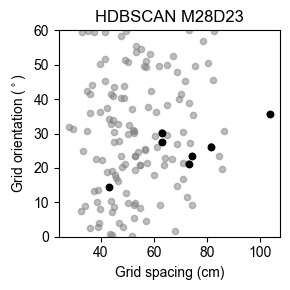

Identified 1 candidate modules


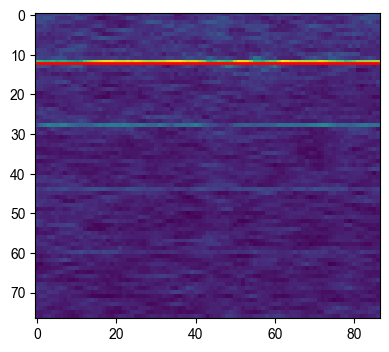

28 23
optimal travel lag is 7.257257257257258 cm based on kde of travel at max spatial information
optimal travel lag is 7.257257257257258 cm
there are 130 non_grid and non_spatial_cells
there are 7 grid_cells
there are 97 non grid spatial cells
there are 33 non spatial cells
there are 0 speed cells
there are 137 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Only one cluster found, attempting to create a new cluster around centroid
Found 1 modules with HDBSCAN for mouse 28 day 23
for each module , the number of points is: [7]


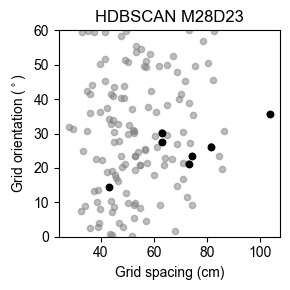

No module_1 cells found for mouse 28, day 23
Skipping session M28_D23.pkl due to missing dominant shank or no module_1 cells.

Processing session: M29_D25.pkl (mouse 29, day 25)
29 25
optimal travel lag is 7.157157157157158 cm based on kde of travel at max spatial information
optimal travel lag is 7.157157157157158 cm
there are 211 non_grid and non_spatial_cells
there are 10 grid_cells
there are 131 non grid spatial cells
there are 80 non spatial cells
there are 0 speed cells
there are 221 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
for the grid cells the unique locations are ['ENTm3' 'ENTm5' 'PAR']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
there are 191 MEC cells
there are 60 PARA cells
there are 0 PRE cells
there are 20 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 271 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated

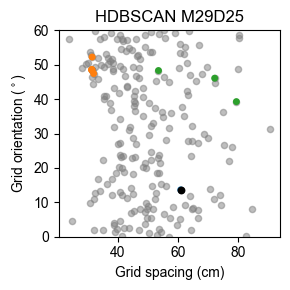

for module 0, there are 6 cells with average spacing 31.541636351465446
for module 1, there are 3 cells with average spacing 68.42440172931934
Identified 1 candidate modules


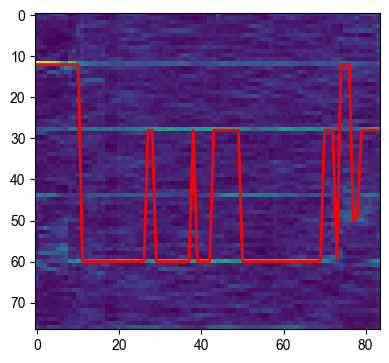

29 25
optimal travel lag is 7.157157157157158 cm based on kde of travel at max spatial information
optimal travel lag is 7.157157157157158 cm
there are 211 non_grid and non_spatial_cells
there are 10 grid_cells
there are 131 non grid spatial cells
there are 80 non spatial cells
there are 0 speed cells
there are 221 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
for the grid cells the unique locations are ['ENTm3' 'ENTm5' 'PAR']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 37.14538670493277
Found 3 modules with HDBSCAN for mouse 29 day 25
for each module , the number of points is: [1 6 3]


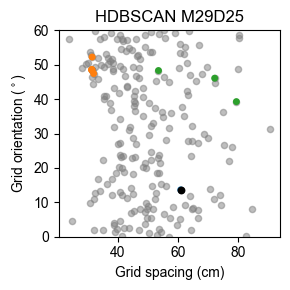

for module 0, there are 6 cells with average spacing 31.541636351465446
for module 1, there are 3 cells with average spacing 68.42440172931934
Module 1 cells for mouse 29, day 25 are mostly on shank 2 (counts: {2: np.int64(6)})
  Group: Module 1
    Module 1 test_cell_ids in group: [np.int64(368), np.int64(370), np.int64(377), np.int64(385), np.int64(387)]
    Module 1: TI mean=-0.032, TA mean=-0.047, n_cells=5, cell_count_mean=4.0
    NGS Same Shank: TI mean=0.004, TA mean=0.099, n_cells=5, cell_count_mean=24.0
    NGS Other Shanks: TI mean=-0.111, TA mean=-0.025, n_cells=5, cell_count_mean=35.7

Processing session: M28_D25.pkl (mouse 28, day 25)
28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial

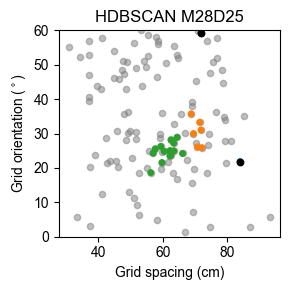

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
Identified 1 candidate modules


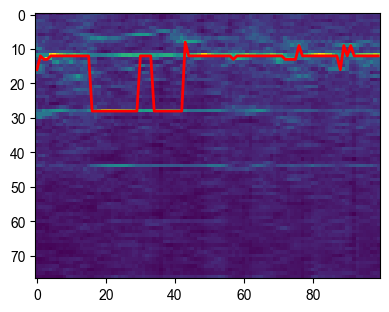

28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 10.95007559047365
Found 3 modules with HDBSCAN for mouse 28 day 25
for each module , the number of points is: [ 2  6 15]


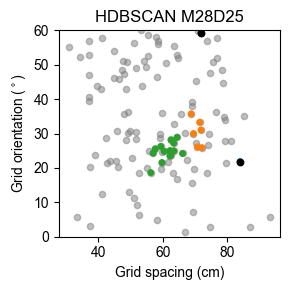

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
Module 1 cells for mouse 28, day 25 are mostly on shank 1 (counts: {1: np.int64(14), 2: np.int64(1)})
  Group: Module 1
    Module 1 test_cell_ids in group: [np.int64(126), np.int64(139), np.int64(147), np.int64(149), np.int64(151), np.int64(153), np.int64(154), np.int64(155), np.int64(156), np.int64(158), np.int64(160), np.int64(162), np.int64(174), np.int64(188), np.int64(284)]
    Module 1: TI mean=0.060, TA mean=0.103, n_cells=15, cell_count_mean=14.0
    NGS Same Shank: TI mean=0.018, TA mean=0.077, n_cells=15, cell_count_mean=10.0
    NGS Other Shanks: TI mean=-0.045, TA mean=0.035, n_cells=15, cell_count_mean=28.0

Processing session: M29_D23.pkl (mouse 29, day 23)
29 23
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 141 non_grid and non_spa

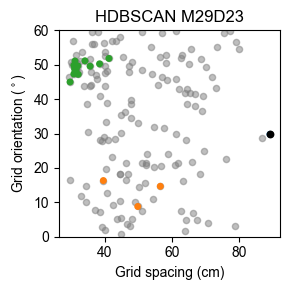

for module 0, there are 3 cells with average spacing 48.661737523324746
for module 1, there are 15 cells with average spacing 32.85775663419034
Identified 1 candidate modules


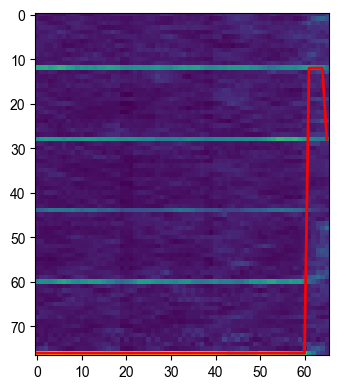

29 23
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 141 non_grid and non_spatial_cells
there are 19 grid_cells
there are 114 non grid spatial cells
there are 27 non spatial cells
there are 0 speed cells
there are 160 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 39.09368458573167
Found 3 modules with HDBSCAN for mouse 29 day 23
for each module , the number of points is: [ 1  3 15]


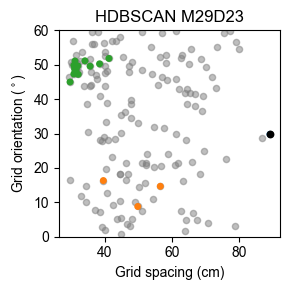

for module 0, there are 3 cells with average spacing 48.661737523324746
for module 1, there are 15 cells with average spacing 32.85775663419034
Module 1 cells for mouse 29, day 23 are mostly on shank 2 (counts: {2: np.int64(11), 3: np.int64(4)})
  Group: Module 1
    Module 1 test_cell_ids in group: [np.int64(160), np.int64(184), np.int64(191), np.int64(194), np.int64(202), np.int64(213), np.int64(214), np.int64(216), np.int64(217), np.int64(219), np.int64(389), np.int64(411)]
    Module 1: TI mean=0.031, TA mean=0.056, n_cells=12, cell_count_mean=11.0
    NGS Same Shank: TI mean=0.039, TA mean=0.056, n_cells=12, cell_count_mean=14.0
    NGS Other Shanks: TI mean=-0.003, TA mean=0.010, n_cells=12, cell_count_mean=33.3

Processing session: M26_D15.pkl (mouse 26, day 15)
26 15
optimal travel lag is 10.660660660660668 cm based on kde of travel at max spatial information
optimal travel lag is 10.660660660660668 cm
there are 133 non_grid and non_spatial_cells
there are 8 grid_cells
there ar

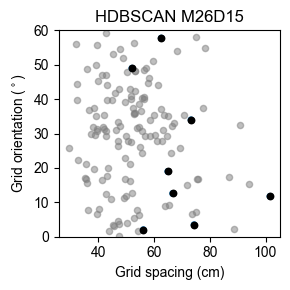

Identified 1 candidate modules


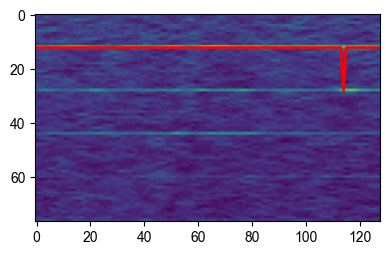

26 15
optimal travel lag is 10.660660660660668 cm based on kde of travel at max spatial information
optimal travel lag is 10.660660660660668 cm
there are 133 non_grid and non_spatial_cells
there are 8 grid_cells
there are 95 non grid spatial cells
there are 38 non spatial cells
there are 0 speed cells
there are 141 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl5']
for the grid cells the unique locations are ['ENTm1' 'ENTm3' 'PAR' 'VISpl5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Only one cluster found, attempting to create a new cluster around centroid
Found 1 modules with HDBSCAN for mouse 26 day 15
for each module , the number of points is: [8]


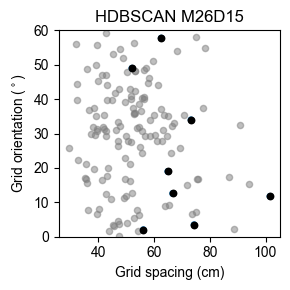

No module_1 cells found for mouse 26, day 15
Skipping session M26_D15.pkl due to missing dominant shank or no module_1 cells.

Processing session: M28_D17.pkl (mouse 28, day 17)
28 17
optimal travel lag is 11.161161161161168 cm based on kde of travel at max spatial information
optimal travel lag is 11.161161161161168 cm
there are 91 non_grid and non_spatial_cells
there are 7 grid_cells
there are 71 non grid spatial cells
there are 20 non spatial cells
there are 0 speed cells
there are 98 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'VISpl5' 'VISpl6a']
unique brain regions ['ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a']
there are 71 MEC cells
there are 7 PARA cells
there are 0 PRE cells
there are 23 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 101 all cells
params min_cluster_size and cluster_selection_epsilon are

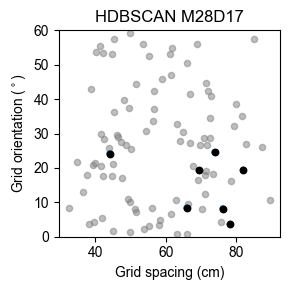

Identified 1 candidate modules


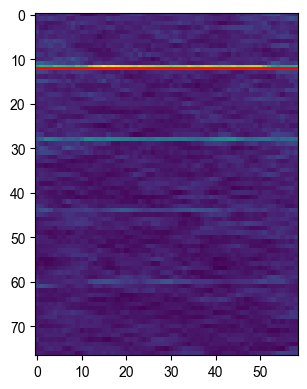

28 17
optimal travel lag is 11.161161161161168 cm based on kde of travel at max spatial information
optimal travel lag is 11.161161161161168 cm
there are 91 non_grid and non_spatial_cells
there are 7 grid_cells
there are 71 non grid spatial cells
there are 20 non spatial cells
there are 0 speed cells
there are 98 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'VISpl5' 'VISpl6a']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Only one cluster found, attempting to create a new cluster around centroid
Found 1 modules with HDBSCAN for mouse 28 day 17
for each module , the number of points is: [7]


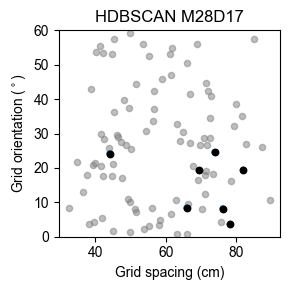

No module_1 cells found for mouse 28, day 17
Skipping session M28_D17.pkl due to missing dominant shank or no module_1 cells.

Processing session: M21_D16.pkl (mouse 21, day 16)
21 16
optimal travel lag is 10.360360360360367 cm based on kde of travel at max spatial information
optimal travel lag is 10.360360360360367 cm
there are 216 non_grid and non_spatial_cells
there are 15 grid_cells
there are 165 non grid spatial cells
there are 51 non spatial cells
there are 0 speed cells
there are 231 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
there are 242 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 242 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated, thes

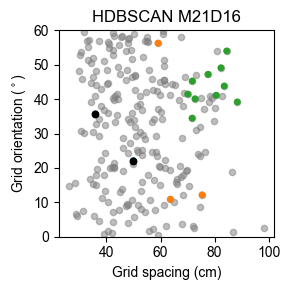

for module 0, there are 3 cells with average spacing 66.0058949975011
for module 1, there are 10 cells with average spacing 78.27797696247492
Identified 1 candidate modules


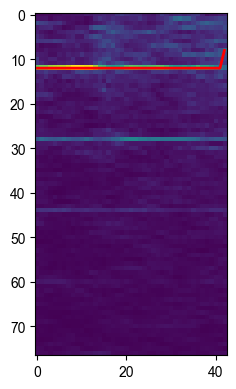

21 16
optimal travel lag is 10.360360360360367 cm based on kde of travel at max spatial information
optimal travel lag is 10.360360360360367 cm
there are 216 non_grid and non_spatial_cells
there are 15 grid_cells
there are 165 non grid spatial cells
there are 51 non spatial cells
there are 0 speed cells
there are 231 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 21.071326809552424
Found 3 modules with HDBSCAN for mouse 21 day 16
for each module , the number of points is: [ 2  3 10]


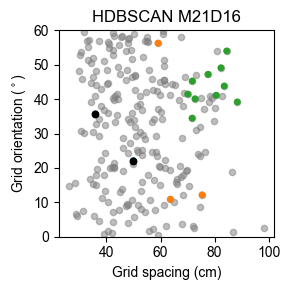

for module 0, there are 3 cells with average spacing 66.0058949975011
for module 1, there are 10 cells with average spacing 78.27797696247492
Module 1 cells for mouse 21, day 16 are mostly on shank 3 (counts: {3: np.int64(2), 2: np.int64(1)})
  Group: Module 1
    Module 1 test_cell_ids in group: []
    No module_1 test_cell_ids in this group.
Session M21_D16.pkl excluded: missing both task-anchored and task-independent firing for module_1 cells.

Processing session: M25_D25.pkl (mouse 25, day 25)
25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/

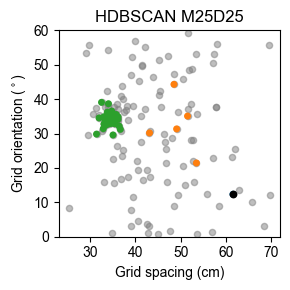

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Identified 1 candidate modules


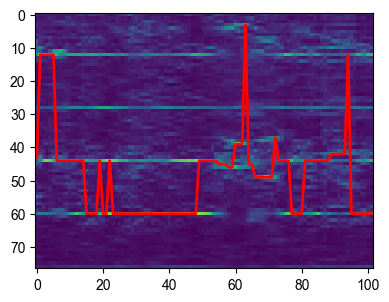

25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 1  5 30]


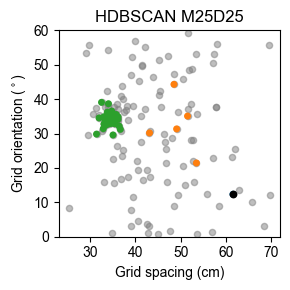

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Module 1 cells for mouse 25, day 25 are mostly on shank 2 (counts: {2: np.int64(14), 1: np.int64(13), 0: np.int64(3)})
  Group: Module 1
    Module 1 test_cell_ids in group: [np.int64(3), np.int64(14), np.int64(15), np.int64(69), np.int64(71), np.int64(76), np.int64(83), np.int64(87), np.int64(91), np.int64(96), np.int64(101), np.int64(104), np.int64(105), np.int64(109), np.int64(111), np.int64(120), np.int64(207), np.int64(214), np.int64(215), np.int64(219), np.int64(227), np.int64(230), np.int64(231), np.int64(232), np.int64(233), np.int64(234), np.int64(235), np.int64(250), np.int64(264)]
    Module 1: TI mean=0.144, TA mean=0.146, n_cells=29, cell_count_mean=28.0
    NGS Same Shank: TI mean=0.039, TA mean=0.061, n_cells=29, cell_count_mean=39.0
    NGS Other Shanks: TI mean=0.043, TA mean=0.060, n_cells=29, cell_count_mean=11.7


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')

results_path = '/Users/harryclark/Downloads/COHORT12/multishank_xgboost/'
pkl_files = [f for f in os.listdir(results_path) if f.endswith('.pkl')]
loaded_pickles = {}
for fname in pkl_files:
    with open(os.path.join(results_path, fname), 'rb') as f:
        loaded_pickles[fname] = pickle.load(f)
print(f"Loaded {len(loaded_pickles)} pickle files:", list(loaded_pickles.keys()))



def get_module_1_dominant_shank(g_m_cluster_ids, locations, mouse, day):
    if len(g_m_cluster_ids) == 0:
        print(f"No module_1 cells found for mouse {mouse}, day {day}")
        return None
    module_1_ids = g_m_cluster_ids[0]
    locs = locations[(locations['mouse'] == mouse) & (locations['day'] == day)]
    shank_counts = locs[locs['cluster_id'].isin(module_1_ids)]['shank_id'].value_counts()
    if len(shank_counts) == 0:
        print(f"No location info for module_1 cells for mouse {mouse}, day {day}")
        return None
    print(f"Module 1 cells for mouse {mouse}, day {day} are mostly on shank {shank_counts.idxmax()} (counts: {dict(shank_counts)})")
    return shank_counts.idxmax()

session_results = []
for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)

    print(f"\nProcessing session: {fname} (mouse {mouse}, day {day})")
    trial_labels, _ = get_trial_labels(mouse, day)

    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )
    module_1_ids = g_m_cluster_ids[0] if len(g_m_cluster_ids) > 0 else []
    dominant_shank = get_module_1_dominant_shank(g_m_cluster_ids, locations, mouse, day)
    if dominant_shank is None or len(module_1_ids) == 0:
        print(f"Skipping session {fname} due to missing dominant shank or no module_1 cells.")
        continue
    # Precompute NGS cells by shank for cell_count logic
    ngs_cells_by_shank = {}
    for shank in range(4):
        ngs_cells_by_shank[shank] = ngs[ngs['shank_id'] == shank]['cluster_id'].tolist()

    # Only analyze test_cell_ids that are module_1 cells
    session_has_both_types = False
    session_temp_results = []
    for group_name, group_df in all_rolling_results_by_group.items():
        if group_name != 'Module 1':
            continue
        print(f"  Group: {group_name}")
        module_1_cells_in_group = [tid for tid in group_df['test_cell_id'].unique() if tid in module_1_ids]
        print(f"    Module 1 test_cell_ids in group: {module_1_cells_in_group}")
        if len(module_1_cells_in_group) == 0:
            print("    No module_1 test_cell_ids in this group.")
            continue

        for pred_label, pred in [
            ('Module 1', 'rolling_pr2_module_1'),
            ('NGS Same Shank', f'rolling_pr2_shank_{dominant_shank}_ngs'),
            ('NGS Other Shanks', None)
        ]:
            vals_ti, vals_ta = [], []
            cell_counts_ti, cell_counts_ta = [], []
            for test_id in module_1_cells_in_group:
                df_cell = group_df[group_df['test_cell_id'] == test_id].reset_index(drop=True)
                if len(df_cell) == 0:
                    continue
                if trial_labels is not None:
                    mask_ti = (trial_labels[:len(df_cell)] == 0)
                    mask_ta = (trial_labels[:len(df_cell)] == 1)
                else:
                    mask_ti = np.zeros(len(df_cell), dtype=bool)
                    mask_ta = np.zeros(len(df_cell), dtype=bool)
                # Calculate cell_count based on predictor type
                if pred_label == 'Module 1':
                    # Number of module_1 cells minus the test cell
                    cell_count = max(len(module_1_cells_in_group) - 1, 0)
                elif pred_label == 'NGS Same Shank':
                    # Number of NGS cells on dominant shank
                    cell_count = len(ngs_cells_by_shank[dominant_shank])
                elif pred_label == 'NGS Other Shanks':
                    # For each shank != dominant_shank, use number of NGS cells on that shank
                    cell_count = np.nan  # Will be set per shank below
                else:
                    cell_count = np.nan
                if pred_label == 'NGS Other Shanks':
                    pr2_vals = []
                    cell_counts_other_shanks = []
                    for shank in [s for s in range(4) if s != dominant_shank]:
                        pred_name = f'rolling_pr2_shank_{shank}_ngs'
                        if pred_name in df_cell:
                            pr2_vals.append(df_cell[pred_name])
                            cell_counts_other_shanks.append(len(ngs_cells_by_shank[shank]))
                    if pr2_vals:
                        pr2_vals = np.nanmean(np.array(pr2_vals), axis=0)
                        vals_ti.append(np.nanmean(pr2_vals[mask_ti]))
                        vals_ta.append(np.nanmean(pr2_vals[mask_ta]))
                        # Use mean of cell_counts_other_shanks for this test_id
                        if cell_counts_other_shanks:
                            cell_counts_ti.append(np.mean(cell_counts_other_shanks))
                            cell_counts_ta.append(np.mean(cell_counts_other_shanks))
                        else:
                            cell_counts_ti.append(np.nan)
                            cell_counts_ta.append(np.nan)
                else:
                    if pred in df_cell:
                        vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
                        vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
                        cell_counts_ti.append(cell_count)
                        cell_counts_ta.append(cell_count)
            print(f"    {pred_label}: TI mean={np.nanmean(vals_ti):.3f}, TA mean={np.nanmean(vals_ta):.3f}, n_cells={len(vals_ti)}, cell_count_mean={np.nanmean(cell_counts_ti):.1f}")
            # Check for both types of firing
            has_ti = not np.isnan(np.nanmean(vals_ti)) and len(vals_ti) > 0
            has_ta = not np.isnan(np.nanmean(vals_ta)) and len(vals_ta) > 0
            if has_ti and has_ta:
                session_has_both_types = True
            session_temp_results.append({
                'mouse': mouse,
                'day': day,
                'session': fname,
                'group': pred_label,
                'task_type': 'Task-Independent',
                'mean_pr2': np.nanmean(vals_ti),
                'sem_pr2': np.nanstd(vals_ti) / np.sqrt(len(vals_ti)) if len(vals_ti) > 0 else np.nan,
                'n_cells': len(vals_ti),
                'cell_count': np.nanmean(cell_counts_ti)
            })
            session_temp_results.append({
                'mouse': mouse,
                'day': day,
                'session': fname,
                'group': pred_label,
                'task_type': 'Task-Anchored',
                'mean_pr2': np.nanmean(vals_ta),
                'sem_pr2': np.nanstd(vals_ta) / np.sqrt(len(vals_ta)) if len(vals_ta) > 0 else np.nan,
                'n_cells': len(vals_ta),
                'cell_count': np.nanmean(cell_counts_ta)
            })
    if session_has_both_types:
        session_results.extend(session_temp_results)
    else:
        print(f"Session {fname} excluded: missing both task-anchored and task-independent firing for module_1 cells.")
results_df = pd.DataFrame(session_results)

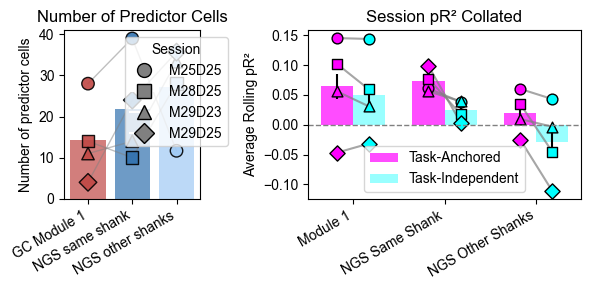

In [304]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D

# --- Data prep ---
# Aggregate cell_count per session and group
cell_count_df = results_df.groupby(['session', 'group'])['cell_count'].mean().unstack(fill_value=0)

groups = ['Module 1', 'NGS Same Shank', 'NGS Other Shanks']
group_colors = ['#c04744', "#3171ae", "#a0caf4"]
task_colors = {'Task-Independent': 'cyan', 'Task-Anchored': 'magenta'}

sessions = cell_count_df.index.tolist()
bar_width = 0.25
width = 0.35

# Define a list of unique marker styles
marker_styles = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '8', 'p', 'H', 'd', '<', '>', '1', '2', '3', '4', '|', '_']
session_marker_map = {session: marker_styles[i % len(marker_styles)] for i, session in enumerate(sessions)}

fig, axes = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={'width_ratios': [0.5, 1]}, sharey=False)

# --- Right subplot: Collated pR² plot ---
ax = axes[1]
for g_idx, g in enumerate(groups):
    df_g = results_df[results_df['group'] == g]
    agg_df = df_g.groupby(['session', 'task_type'])['mean_pr2'].mean().unstack()
    agg_df = agg_df.dropna(subset=['Task-Anchored', 'Task-Independent'])
    for session, row in agg_df.iterrows():
        mouse = results_df[(results_df['session'] == session) & (results_df['group'] == g)]['mouse'].values[0]
        day = results_df[(results_df['session'] == session) & (results_df['group'] == g)]['day'].values[0]
        ti_val = row['Task-Independent']
        ta_val = row['Task-Anchored']
        marker = session_marker_map[session]
        ax.plot([g_idx+width/2, g_idx-width/2], [ti_val, ta_val], color='grey', alpha=0.7, zorder=1)
        ax.scatter(g_idx+width/2, ti_val, color=task_colors['Task-Independent'], edgecolor='k', s=60, zorder=2, marker=marker)
        ax.scatter(g_idx-width/2, ta_val, color=task_colors['Task-Anchored'], edgecolor='k', s=60, zorder=2, marker=marker)
# Plot summary bars
for i, task_type in enumerate(['Task-Anchored', 'Task-Independent']):
    df = results_df[results_df['task_type'] == task_type].groupby('group').agg({'mean_pr2': 'mean', 'sem_pr2': 'mean', 'n_cells': 'sum', 'session': 'nunique'}).reset_index()
    means = [df[df['group'] == g]['mean_pr2'].values[0] if not df[df['group'] == g].empty else np.nan for g in groups]
    sems = [df[df['group'] == g]['sem_pr2'].values[0] if not df[df['group'] == g].empty else np.nan for g in groups]
    for j, g in enumerate(groups):
        ax.bar(j + (i-0.5)*width, means[j], width, yerr=sems[j], label=task_type if j==0 else "", alpha=0.7 if i==0 else 0.4, color=task_colors[task_type], zorder=0)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(np.arange(len(groups)))
ax.set_xticklabels(groups, rotation=30, ha='right')
ax.set_ylabel('Average Rolling pR²')
ax.set_title('Session pR² Collated')
ax.legend()
ax.set_yticks([-0.1, -0.05, 0, 0.05, 0.1, 0.15])

# --- Left subplot: Cell count summary plot ---
ax = axes[0]
avg_cell_count = [cell_count_df[g].mean() if g in cell_count_df.columns else np.nan for g in groups]
x = np.arange(len(groups))
ax.bar(x, avg_cell_count, color=group_colors, alpha=0.7, label='Average cell_count')
for session in cell_count_df.index:
    yvals = [cell_count_df.loc[session, g] if g in cell_count_df.columns else np.nan for g in groups]
    ax.plot(x, yvals, color='grey', alpha=0.5, linewidth=1, zorder=1)
    marker = session_marker_map[session]
    ax.scatter(x, yvals, color=group_colors, edgecolor='k', s=80, zorder=2, alpha=0.9, marker=marker)
ax.set_xticks(x)
ax.set_xticklabels(['GC Module 1', 'NGS same shank', 'NGS other shanks'], rotation=30, ha='right')
ax.set_title('Number of Predictor Cells')
ax.set_ylabel('Number of predictor cells')

# Add legend for session markers (right subplot)
legend_elements = [Line2D([0], [0], marker=session_marker_map[session], color='w', markerfacecolor='grey', markeredgecolor='k', markersize=10, label=session.replace('_', '').replace('.pkl', '')) for session in cell_count_df.index]
ax.legend(handles=legend_elements, title='Session', loc='upper right', bbox_to_anchor=(1.25, 1))

fig.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/multishank_combined_summary.pdf', dpi=1000)
plt.show()

In [ ]:

predictors = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_shank_0_ngs',
    'rolling_pr2_shank_1_ngs',
    'rolling_pr2_shank_2_ngs',
    'rolling_pr2_shank_3_ngs',
    'rolling_pr2_all_cells',
]
labels = [
    'Position',
    'Module 1',
    'Shank 0 NGS',
    'Shank 1 NGS',
    'Shank 2 NGS',
    'Shank 3 NGS',
    'All Cells',
]
colors = ['#000000', '#c04744', "#a0caf4", '#3171ae', '#a0caf4', '#a0caf4', '#50104c']
err_colors = {'Task-Independent': 'cyan', 'Task-Anchored': 'magenta'}

for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)
    if (mouse != 28) or (day != 25):
        continue
    trial_labels, got_from_grid = get_trial_labels(mouse, day)
    print(f'{np.unique(trial_labels)}')
    print(f'mouse {mouse}, day {day}, TA label from grid: {got_from_grid}')
    # Get cell counts for annotation
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )

    figpath_rm = f'/Users/harryclark/Desktop/M{mouse}D{day}'
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'GC', figpath=figpath_rm)
    for shank in range(4):
        plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=ngs[ngs['shank_id'] == shank].cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'NGS Shank {shank}', figpath=figpath_rm)

    cell_counts = [
        0,  # Position (all cells)
        len(g_m_cluster_ids[0]) if len(g_m_cluster_ids) > 0 else 0,  # Module 1
        len(ngs[ngs['shank_id'] == 0]),
        len(ngs[ngs['shank_id'] == 1]),
        len(ngs[ngs['shank_id'] == 2]),
        len(ngs[ngs['shank_id'] == 3]),
        len(all.cluster_id.values),  # All cells
    ]
    groups = list(all_rolling_results_by_group.keys())
    fig, axes = plt.subplots(2, len(groups), figsize=(16/1.1, 6/1.1), sharey=False)
    # Define custom y-limits for each group
    custom_top_ylim = {
        'Module 1': (-0.3, 0.3),
        'Shank 0 NGS': (-0.3, 0.3),
        'Shank 1 NGS': (-0.3, 0.3),
        'Shank 2 NGS': (-0.06, 0.06),
        'Shank 3 NGS': (-0.2, 0.2),
    }
    custom_bottom_ylim = {
        'Module 1': (-0.15, 0.35),
        'Shank 0 NGS': (-0.15, 0.4),
        'Shank 1 NGS': (-0.15, 0.4),
        'Shank 2 NGS': (-0.03, 0.1),
        'Shank 3 NGS': (-0.03, 0.1),
    }

    for col_idx, group_name in enumerate(groups):
        group_df = all_rolling_results_by_group[group_name]
        test_ids = group_df['test_cell_id'].unique()
        ax_top = axes[0, col_idx]
        for i, pred in enumerate(predictors):
            mean_df = group_df.groupby('trial_number')[pred].mean()
            sem_df = group_df.groupby('trial_number')[pred].sem()
            ax_top.plot(mean_df.index, mean_df.values, color=colors[i], label=labels[i])
            ax_top.fill_between(mean_df.index, mean_df.values - sem_df.values, mean_df.values + sem_df.values, color=colors[i], alpha=0.2)
        ax_top.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_top.set_xlabel('Trial Number')
        ax_top.set_title(f'Target cells: {group_name}')
        # Set custom ylim for ax_top if available
        if group_name in custom_top_ylim:
            ax_top.set_ylim(custom_top_ylim[group_name])
        if col_idx == 0:
            ax_top.set_ylabel('Rolling pR²')
        else:
            ax_top.set_ylabel('')
        if trial_labels is not None:
            for label, c in zip([0,1], ['cyan', 'magenta']):
                ax_top.scatter(np.arange(mean_df.index[0], len(trial_labels) + mean_df.index[0])[trial_labels == label], np.ones(len(trial_labels))[trial_labels == label]*ax_top.get_ylim()[1], color=c)

        ax_bottom = axes[1, col_idx]
        means_ti, means_ta, sems_ti, sems_ta = [], [], [], []
        for pred in predictors:
            vals_ti, vals_ta = [], []
            for test_id in test_ids:
                df_cell = group_df[group_df['test_cell_id'] == test_id].reset_index(drop=True)
                if trial_labels is not None:
                    mask_ti = (trial_labels[:len(df_cell)] == 0)
                    mask_ta = (trial_labels[:len(df_cell)] == 1)
                else:
                    mask_ti = np.zeros(len(df_cell), dtype=bool)
                    mask_ta = np.zeros(len(df_cell), dtype=bool)
                vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
                vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
            means_ti.append(np.nanmean(vals_ti))
            means_ta.append(np.nanmean(vals_ta))
            sems_ti.append(np.nanstd(vals_ti) / np.sqrt(len(vals_ti)))
            sems_ta.append(np.nanstd(vals_ta) / np.sqrt(len(vals_ta)))
        x = np.arange(len(predictors))
        width = 0.35
        # Bar plots
        bars1 = ax_bottom.bar(
            x - width/2, means_ti, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Independent'
        )
        bars2 = ax_bottom.bar(
            x + width/2, means_ta, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Anchored'
        )
        # Manually add colored error bars
        for i in range(len(predictors)):
            ax_bottom.errorbar(
                x[i] - width/2, means_ti[i], yerr=sems_ti[i],
                fmt='none', ecolor=err_colors['Task-Independent'], elinewidth=2, capsize=0, zorder=3
            )
            ax_bottom.errorbar(
                x[i] + width/2, means_ta[i], yerr=sems_ta[i],
                fmt='none', ecolor=err_colors['Task-Anchored'], elinewidth=2, capsize=0, zorder=3
            )
        # Annotate cell counts above each bar
        for i in range(len(predictors)):
            ax_bottom.text(x[i], max(means_ti[i]+sems_ti[i], means_ta[i]+sems_ta[i]), f'n={cell_counts[i]}', ha='center', va='bottom', fontsize=10, color=colors[i])
        ax_bottom.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(labels, rotation=30, ha='right')
        # Set custom ylim for ax_bottom if available
        if group_name in custom_bottom_ylim:
            ax_bottom.set_ylim(custom_bottom_ylim[group_name])
        else:
            ax_bottom.set_ylim([-0.1, None])
        if col_idx == 0:
            ax_bottom.set_ylabel('Average Rolling pR²')
        else:
            ax_bottom.set_ylabel('')
    fig.tight_layout()
    plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M28D25_rolling_predictors.pdf')
    plt.show()

25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 1  5 30]


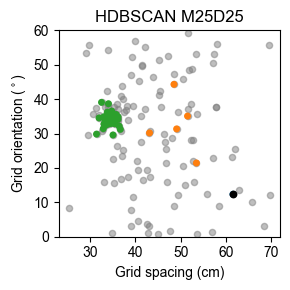

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Identified 1 candidate modules


In [12]:
mouse = 25
day = 25

gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)

ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
    gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
    figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
)
tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False) 

tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in g_m_cluster_ids[0] if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3]
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring
labels = np.isin(max_peaks, [28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring


In [220]:

tmp = pd.DataFrame()  # temporary DataFrame to hold 
tmp['cluster_id'] = [cluster_id]
tmp['shank_id'] = [shank_id]
tmp['shank_type'] = [shank_type]
tmp['cell_type'] = [cell_type]
tmp['mouse_id'] = [mouse]
tmp['day_id'] = [day]
tmp['firing_mode'] = [firing_mode]
tmp['spatial_info'] = [spatial_info]

In [221]:
tmp

,cluster_id,shank_id,shank_type,cell_type,mouse_id,day_id,firing_mode,spatial_info
0,47,0,across_shank,GC,29,25,TA,0.0


29 25
optimal travel lag is 7.157157157157158 cm based on kde of travel at max spatial information
optimal travel lag is 7.157157157157158 cm
there are 211 non_grid and non_spatial_cells
there are 10 grid_cells
there are 131 non grid spatial cells
there are 80 non spatial cells
there are 0 speed cells
there are 221 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
for the grid cells the unique locations are ['ENTm3' 'ENTm5' 'PAR']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 37.14538670493277
Found 3 modules with HDBSCAN for mouse 29 day 25
for each module , the number of points is: [1 6 3]


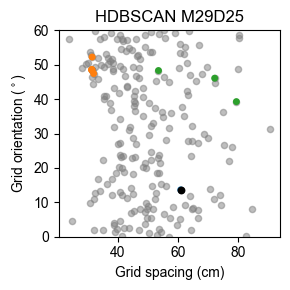

for module 0, there are 6 cells with average spacing 31.541636351465446
for module 1, there are 3 cells with average spacing 68.42440172931934
Identified 1 candidate modules


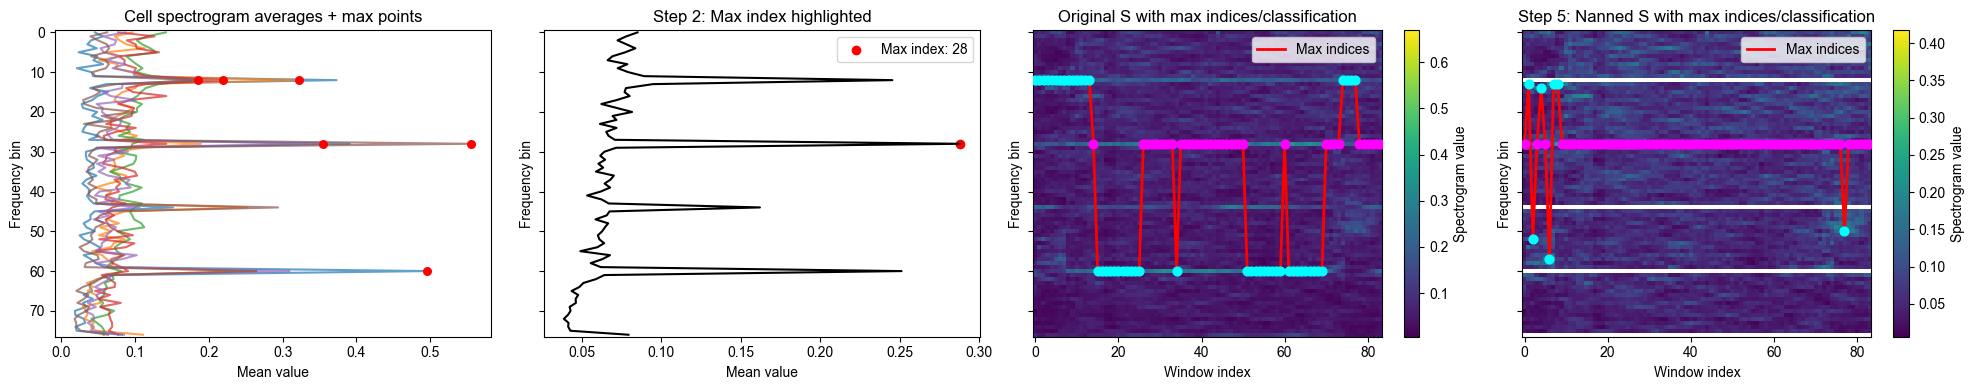

for mouse 29, day 25, labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 1 1 1 1]
Module 1 cells for mouse 29, day 25 are mostly on shank 2 (counts: {2: np.int64(6)})
28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 10.95007559047365
Found 3 modules with HDBSCAN fo

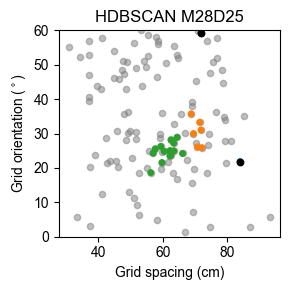

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
Identified 1 candidate modules


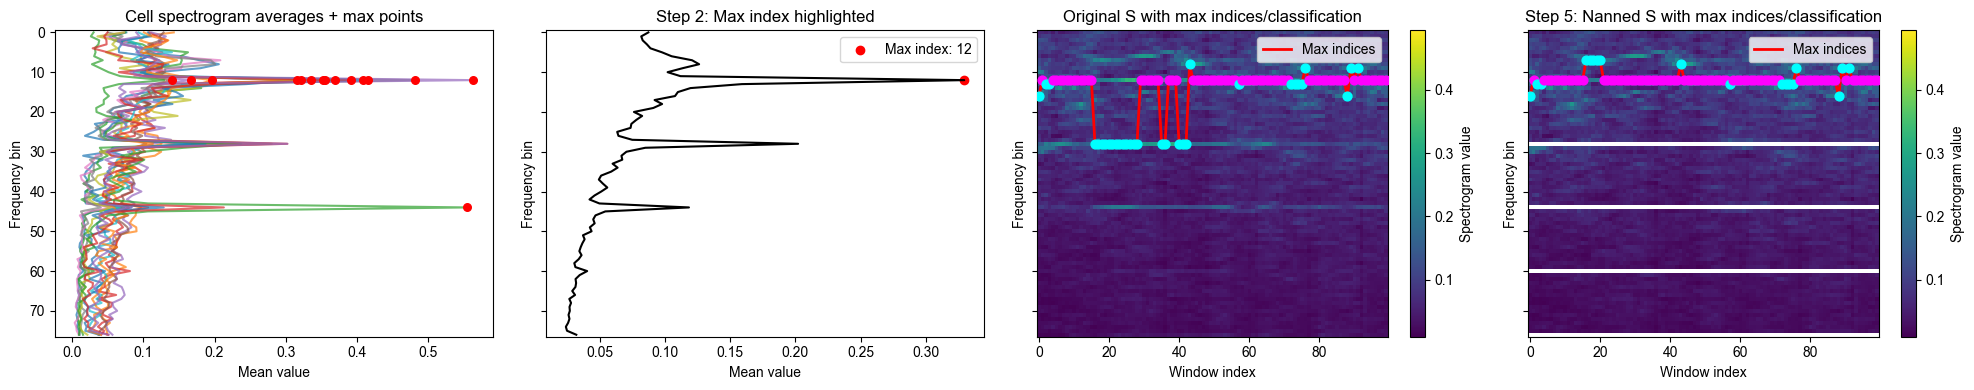

for mouse 28, day 25, labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1
 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Module 1 cells for mouse 28, day 25 are mostly on shank 1 (counts: {1: np.int64(14), 2: np.int64(1)})
29 23
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 141 non_grid and non_spatial_cells
there are 19 grid_cells
there are 114 non grid spatial cells
there are 27 non spatial cells
there are 0 speed cells
there are 160 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 39

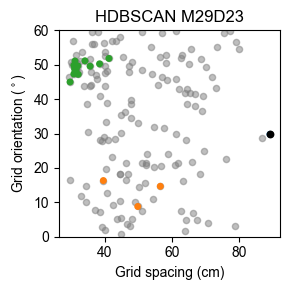

for module 0, there are 3 cells with average spacing 48.661737523324746
for module 1, there are 15 cells with average spacing 32.85775663419034
Identified 1 candidate modules


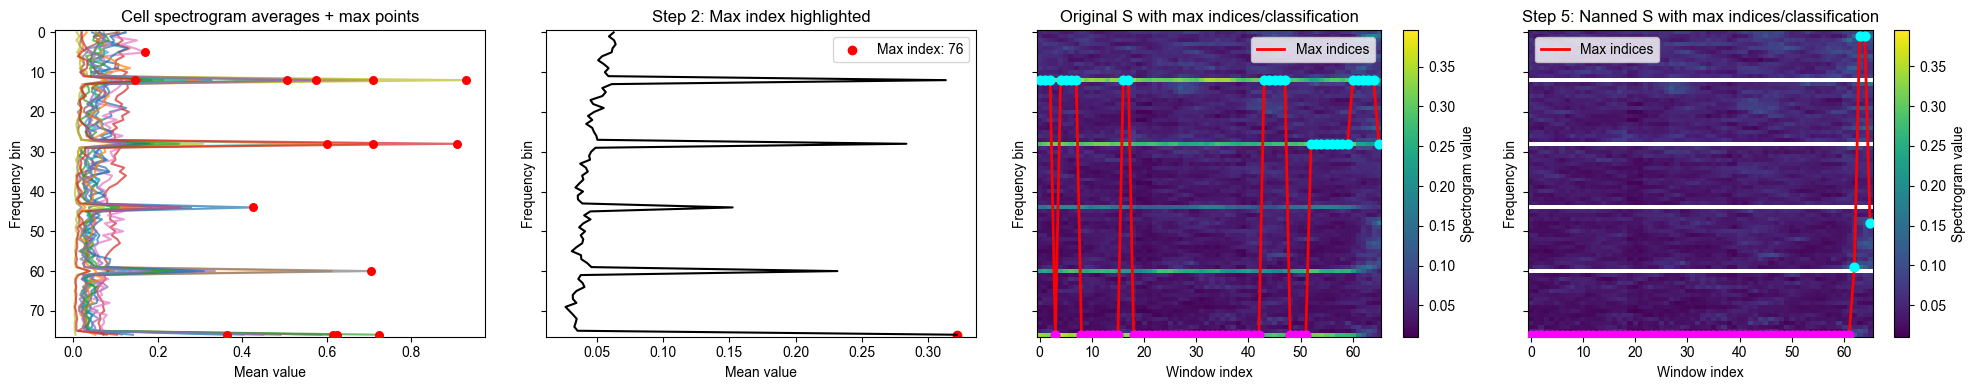

for mouse 29, day 23, labels: [0 0 0 1 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1]
Module 1 cells for mouse 29, day 23 are mostly on shank 2 (counts: {2: np.int64(11), 3: np.int64(4)})
25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 2

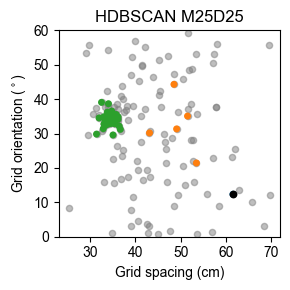

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Identified 1 candidate modules


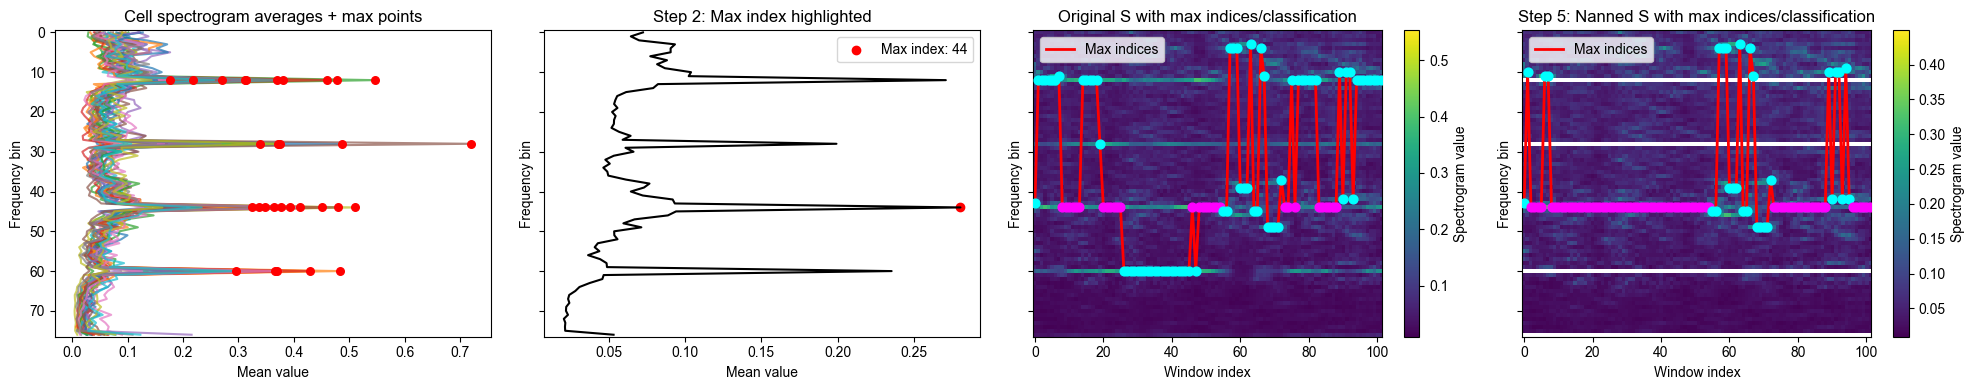

for mouse 25, day 25, labels: [0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
Module 1 cells for mouse 25, day 25 are mostly on shank 2 (counts: {2: np.int64(14), 1: np.int64(13), 0: np.int64(3)})


In [ ]:
import pandas as pd

multishank_results_df = pd.DataFrame()

sessions_of_interest = [(25, 25), (28, 25), (29, 23), (29, 25)]
for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)
    if (mouse, day) not in sessions_of_interest:
        continue

    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')

    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )
    tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False) 

    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in g_m_cluster_ids[0] if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3]

    # get labels from spectrogram
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    labels = np.isin(max_peaks, [28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring

    print(f'for mouse {mouse}, day {day}, labels: {labels}')
    gcs['cell_type'] = 'GC'
    ngs['cell_type'] = 'NGS'
    all_cells = pd.concat([gcs, ngs], ignore_index=True)

    dominant_shank = get_module_1_dominant_shank(g_m_cluster_ids, locations, mouse, day)
    
    # For each cell
    for _, cell in all_cells.iterrows():
        cluster_id = cell['cluster_id']
        shank_id = cell['shank_id']
        shank_type = 'same_shank' if shank_id == dominant_shank else 'across_shank'
        cell_type = cell['cell_type']

        tc = tcs[cluster_id]
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin] # only want bins with ephys data in it
        tcz = zscore(tc)
        bin_config = get_bin_config('VR')
        trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
 
        for firing_mode, label in zip(['TA', 'TI'], [1, 0]):
            trials = beh['trials'][:len(trial_labels)]
            trials = trials[trial_labels == label]
            x, y = get_avg_profile(tc, bs, tl, mask=trial_labels==label)

            spatial_info = nap.compute_1d_mutual_info(y.reshape(-1, 1), 
                                                        beh['P'], 
                                                        ep=beh['moving'].intersect(trials), 
                                                        minmax=bin_config['P']['bounds'])['SI'].iloc[0]

            tmp = pd.DataFrame()  # temporary DataFrame to hold 
            tmp['cluster_id'] = [cluster_id]
            tmp['shank_id'] = [shank_id]
            tmp['shank_type'] = [shank_type]
            tmp['cell_type'] = [cell_type]
            tmp['mouse_id'] = [mouse]
            tmp['day_id'] = [day]
            tmp['firing_mode'] = [firing_mode]
            tmp['spatial_info'] = [spatial_info]
            multishank_results_df = pd.concat([multishank_results_df, tmp], ignore_index=True)
        

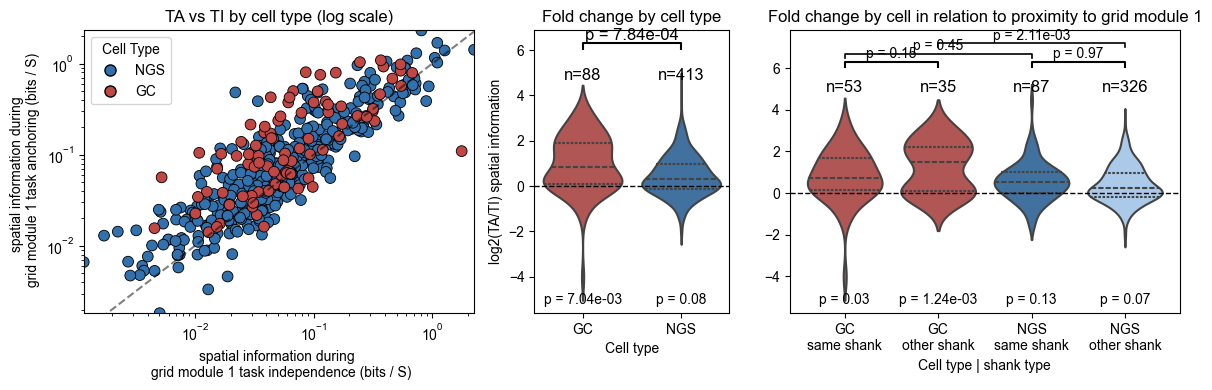

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf

# Use multishank_results_df for all operations
# Pivot to get TA and TI spatial_info per cell
df_tidy = multishank_results_df.pivot_table(
    index=['cluster_id','shank_id','shank_type','cell_type','mouse_id','day_id'],
    columns='firing_mode', values='spatial_info'
 ).reset_index()
df_tidy = df_tidy.dropna(subset=['TA','TI'])

# Calculate log2 fold change (TA/TI)
df_tidy['log2_fc'] = np.log2(df_tidy['TA'] / df_tidy['TI'])

# Rename shank_type for plotting
shank_type_map = {'same_shank': 'same shank', 'across_shank': 'other shank'}
df_tidy['shank_type'] = df_tidy['shank_type'].replace(shank_type_map)

# Set plotting order for cell_type and cell_shank
cell_type_order = ['GC', 'NGS']
cell_type_order_plot = ['NGS', 'GC']  # For scatter: plot NGS first, then GC
cell_shank_order = [
    'GC | same shank', 'GC | other shank',
    'NGS | same shank', 'NGS | other shank'
]
cell_shank_order_nl = [
    'GC\nsame shank', 'GC\nother shank',
    'NGS\nsame shank', 'NGS\nother shank'
]
cell_shank_map = dict(zip(cell_shank_order, cell_shank_order_nl))
df_tidy['cell_shank'] = df_tidy['cell_type'].astype(str) + ' | ' + df_tidy['shank_type'].astype(str)
df_tidy['cell_shank_nl'] = df_tidy['cell_shank'].map(cell_shank_map)

# Define custom colors
custom_palette = {'GC': '#c04744', 'NGS': '#3171ae'}
custom_shank_palette = {
    'GC | same shank': '#c04744',
    'GC | other shank': '#c04744',
    'NGS | same shank': '#3171ae',
    'NGS | other shank': '#a0caf4'
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4), width_ratios=[1,0.5,1])

# 1. Scatter plot: TA vs TI, colored by cell_type, log scale
for ct in cell_type_order_plot:
    sns.scatterplot(
        data=df_tidy[df_tidy['cell_type'] == ct], x='TI', y='TA', hue='cell_type',
        palette=custom_palette, s=60, edgecolor='k', ax=axes[0], legend=False
    )
# Set x/y limits to min/max of data points
x_min, x_max = df_tidy['TI'].min(), df_tidy['TI'].max()
y_min, y_max = df_tidy['TA'].min(), df_tidy['TA'].max()
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)
axes[0].plot([x_min, x_max], [x_min, x_max], 'k--', alpha=0.5)
axes[0].set_xlabel('spatial information during \n grid module 1 task independence (bits / S)')
axes[0].set_ylabel('spatial information during \n grid module 1 task anchoring (bits / S)')
axes[0].set_title('TA vs TI by cell type (log scale)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_palette['NGS'], markeredgecolor='k', label='NGS', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_palette['GC'], markeredgecolor='k', label='GC', markersize=8)
], title='Cell Type')
axes[0].grid(False)  # Remove gridlines

# 2. Violin plot: log2 fold change by cell_type, order GC then NGS
sns.violinplot(
    data=df_tidy, x='cell_type', y='log2_fc', inner='quartile', linestyle='solid', linewidth=1.5,
    palette=[custom_palette[c] for c in cell_type_order], ax=axes[1], order=cell_type_order
)
axes[1].set_xlabel('Cell type')
axes[1].set_ylabel('log2(TA/TI) spatial information')
axes[1].set_title('Fold change by cell type')
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)  # Add horizontal line at 0

# Add n numbers to cell_type violin plot
for i, cell_type in enumerate(cell_type_order):
    n = (df_tidy['cell_type'] == cell_type).sum()
    axes[1].text(i, axes[1].get_ylim()[1]*0.95, f'n={n}', ha='center', va='top', fontsize=12, color='k')

def format_pval(p):
    if np.isnan(p):
        return 'p = n/a'
    elif p < 0.01:
        return f'p = {p:.2e}'
    else:
        return f'p = {p:.2f}'

# --- LME for GC vs NGS (middle plot) ---
formula = "log2_fc ~ cell_type"
try:
    md = smf.mixedlm(
        formula,
        df_tidy,
        groups=df_tidy["mouse_id"],
        re_formula="~1",
        vc_formula={
            "day": "0 + C(day_id)",
            "cluster": "0 + C(cluster_id)",
        }
    )
    mdf = md.fit()
    pval_gc_ngs = mdf.pvalues.get("cell_type[T.NGS]", np.nan)
except Exception as e:
    print(f"GC vs NGS: LME model failed: {e}")
    pval_gc_ngs = np.nan

# Annotate p-value with connecting line
ymax = axes[1].get_ylim()[1]
ymax = 6
axes[1].plot([0, 0, 1, 1], [ymax*1.01, ymax*1.05, ymax*1.05, ymax*1.01], color='k', lw=1.5)
axes[1].text(0.5, ymax*1.055, format_pval(pval_gc_ngs), ha='center', va='bottom', fontsize=12, color='k')

# --- LME for each group vs zero (middle plot, refit with each group as reference) ---
for i, cell_type in enumerate(cell_type_order):
    df_tidy['cell_type_relevel'] = pd.Categorical(df_tidy['cell_type'], categories=cell_type_order)
    df_tidy['cell_type_relevel'] = df_tidy['cell_type_relevel'].cat.reorder_categories([cell_type] + [ct for ct in cell_type_order if ct != cell_type], ordered=True)
    formula0 = "log2_fc ~ cell_type_relevel"
    pval0 = np.nan
    try:
        md0 = smf.mixedlm(
            formula0,
            df_tidy,
            groups=df_tidy["mouse_id"],
            re_formula="~1",
            vc_formula={
                "day": "0 + C(day_id)",
                "cluster": "0 + C(cluster_id)",
            }
        )
        mdf0 = md0.fit()
        pval0 = mdf0.pvalues.get("Intercept", np.nan)
    except Exception as e:
        print(f"{cell_type} vs zero: LME model failed: {e}")
    # Place annotation just above the bottom axis line
    axes[1].text(i, axes[1].get_ylim()[0]+0.02*(axes[1].get_ylim()[1]-axes[1].get_ylim()[0]),
                 format_pval(pval0),
                 ha='center', va='bottom', fontsize=10, color='k')

# 3. Violin plot: log2 fold change by cell_type and shank_type, order GC then NGS
sns.violinplot(
    data=df_tidy, x='cell_shank_nl', y='log2_fc', inner='quartile', linestyle='solid', linewidth=1.5,
    palette=[custom_shank_palette[c] for c in cell_shank_order], ax=axes[2], order=cell_shank_order_nl
)
axes[2].set_xlabel('Cell type | shank type')
axes[2].set_title('Fold change by cell in relation to proximity to grid module 1')
axes[2].axhline(0, color='k', linestyle='--', linewidth=1)  # Add horizontal line at 0
axes[2].set_ylabel('')

# Add n numbers to cell_shank violin plot
for i, cell_shank in enumerate(cell_shank_order):
    n = (df_tidy['cell_shank'] == cell_shank).sum()
    axes[2].text(i, axes[2].get_ylim()[1]*0.95, f'n={n}', ha='center', va='top', fontsize=12, color='k')

# --- LME for GC same shank vs GC other shank (right plot) ---
df_gc = df_tidy[df_tidy['cell_type'] == 'GC'].copy()
df_gc['shank_comp'] = df_gc['cell_shank'].apply(lambda x: 'same' if 'same shank' in x else 'other')
if df_gc['shank_comp'].nunique() == 2 and (df_gc['shank_comp'].value_counts() > 1).all():
    formula_gc = "log2_fc ~ shank_comp"
    try:
        md_gc = smf.mixedlm(
            formula_gc,
            df_gc,
            groups=df_gc["mouse_id"],
            re_formula="~1",
            vc_formula={
                "day": "0 + C(day_id)",
                "cluster": "0 + C(cluster_id)",
            }
        )
        mdf_gc = md_gc.fit()
        pval_gc = mdf_gc.pvalues.get("shank_comp[T.same]", np.nan)
    except Exception as e:
        print(f"GC same shank vs other shank: LME model failed: {e}")
        pval_gc = np.nan
    y = 6
    axes[2].plot([0, 0, 1, 1], [y*1.01, y*1.05, y*1.05, y*1.01], color='k', lw=1.5)
    axes[2].text(0.5, y*1.055, format_pval(pval_gc), ha='center', va='bottom', fontsize=10, color='k')
else:
    print("GC same shank vs other shank: p-value is NaN because there is insufficient data in one or both groups.")

# --- LME for NGS same shank vs NGS other shank (right plot) ---
df_ngs = df_tidy[df_tidy['cell_type'] == 'NGS'].copy()
df_ngs['shank_comp'] = df_ngs['cell_shank'].apply(lambda x: 'same' if 'same shank' in x else 'other')
if df_ngs['shank_comp'].nunique() == 2 and (df_ngs['shank_comp'].value_counts() > 1).all():
    formula_ngs = "log2_fc ~ shank_comp"
    try:
        md_ngs = smf.mixedlm(
            formula_ngs,
            df_ngs,
            groups=df_ngs["mouse_id"],
            re_formula="~1",
            vc_formula={
                "day": "0 + C(day_id)",
                "cluster": "0 + C(cluster_id)",
            }
        )
        mdf_ngs = md_ngs.fit()
        pval_ngs = mdf_ngs.pvalues.get("shank_comp[T.same]", np.nan)
    except Exception as e:
        print(f"NGS same shank vs other shank: LME model failed: {e}")
        pval_ngs = np.nan
    y = 6
    axes[2].plot([2, 2, 3, 3], [y*1.01, y*1.05, y*1.05, y*1.01], color='k', lw=1.5)
    axes[2].text(2.5, y*1.055, format_pval(pval_ngs), ha='center', va='bottom', fontsize=10, color='k')
else:
    print("NGS same shank vs other shank: p-value is NaN because there is insufficient data in one or both groups.")

# --- LME for GC vs NGS within same shank and other shank (additional comparisons) ---
# GC same shank vs NGS same shank
df_same = df_tidy[df_tidy['shank_type'] == 'same shank'].copy()
if df_same['cell_type'].nunique() == 2 and (df_same['cell_type'].value_counts() > 1).all():
    formula_same = "log2_fc ~ cell_type"
    try:
        md_same = smf.mixedlm(
            formula_same,
            df_same,
            groups=df_same["mouse_id"],
            re_formula="~1",
            vc_formula={
                "day": "0 + C(day_id)",
                "cluster": "0 + C(cluster_id)",
            }
        )
        mdf_same = md_same.fit()
        pval_same = mdf_same.pvalues.get("cell_type[T.NGS]", np.nan)
        axes[2].plot([0, 0, 2, 2], [6.5, 6.7, 6.7, 6.5], color='k', lw=1.2)
        axes[2].text(1, 6.72, format_pval(pval_same), ha='center', va='bottom', fontsize=10, color='k')
    except Exception as e:
        print(f"GC vs NGS (same shank): LME model failed: {e}")
else:
    print("GC vs NGS (same shank): insufficient data for LME.")

# GC other shank vs NGS other shank
df_other = df_tidy[df_tidy['shank_type'] == 'other shank'].copy()
if df_other['cell_type'].nunique() == 2 and (df_other['cell_type'].value_counts() > 1).all():
    formula_other = "log2_fc ~ cell_type"
    try:
        md_other = smf.mixedlm(
            formula_other,
            df_other,
            groups=df_other["mouse_id"],
            re_formula="~1",
            vc_formula={
                "day": "0 + C(day_id)",
                "cluster": "0 + C(cluster_id)",
            }
        )
        mdf_other = md_other.fit()
        pval_other = mdf_other.pvalues.get("cell_type[T.NGS]", np.nan)
        axes[2].plot([1, 1, 3, 3], [7.0, 7.2, 7.2, 7.0], color='k', lw=1.2)
        axes[2].text(2, 7.22, format_pval(pval_other), ha='center', va='bottom', fontsize=10, color='k')
    except Exception as e:
        print(f"GC vs NGS (other shank): LME model failed: {e}")
else:
    print("GC vs NGS (other shank): insufficient data for LME.")

# --- LME for each group vs zero (right plot, refit with each group as reference) ---
for i, cell_shank in enumerate(cell_shank_order):
    df_tidy['cell_shank_relevel'] = pd.Categorical(df_tidy['cell_shank'], categories=cell_shank_order)
    df_tidy['cell_shank_relevel'] = df_tidy['cell_shank_relevel'].cat.reorder_categories([cell_shank] + [cs for cs in cell_shank_order if cs != cell_shank], ordered=True)
    formula0 = "log2_fc ~ cell_shank_relevel"
    pval0 = np.nan
    try:
        md0 = smf.mixedlm(
            formula0,
            df_tidy,
            groups=df_tidy["mouse_id"],
            re_formula="~1",
            vc_formula={
                "day": "0 + C(day_id)",
                "cluster": "0 + C(cluster_id)",
            }
        )
        mdf0 = md0.fit(method="powell", maxiter=5000)
        pval0 = mdf0.pvalues.get("Intercept", np.nan)
    except Exception as e:
        print(f"{cell_shank} vs zero: LME model failed: {e}")
    # Place annotation just above the bottom axis line
    axes[2].text(i, axes[2].get_ylim()[0]+0.02*(axes[2].get_ylim()[1]-axes[2].get_ylim()[0]),
                 format_pval(pval0),
                 ha='center', va='bottom', fontsize=10, color='k')

axes[2].set_xticklabels(cell_shank_order_nl)
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/multishank_task_anchoring_spatial_information_changes.pdf', dpi=500)
plt.show() 

25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 1  5 30]


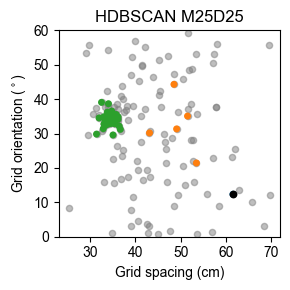

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 10.95007559047365
Found 3 modules with HDBSCAN for mouse 28 day 25
for each module , the number of points is: [ 2  6 15]


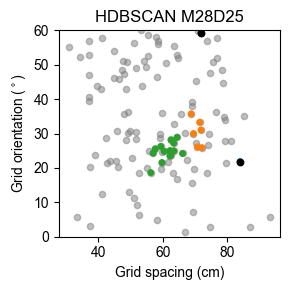

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
29 23
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 141 non_grid and non_spatial_cells
there are 19 grid_cells
there are 114 non grid spatial cells
there are 27 non spatial cells
there are 0 speed cells
there are 160 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 39.09368458573167
Found 3 modules with HDBSCAN for mouse 29 day 23
for each module , the number of points is: [ 1  3 15]


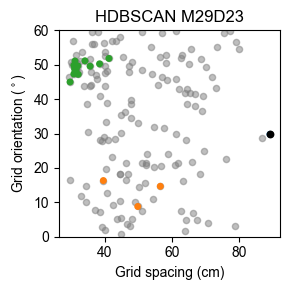

for module 0, there are 3 cells with average spacing 48.661737523324746
for module 1, there are 15 cells with average spacing 32.85775663419034
29 25
optimal travel lag is 7.157157157157158 cm based on kde of travel at max spatial information
optimal travel lag is 7.157157157157158 cm
there are 211 non_grid and non_spatial_cells
there are 10 grid_cells
there are 131 non grid spatial cells
there are 80 non spatial cells
there are 0 speed cells
there are 221 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
for the grid cells the unique locations are ['ENTm3' 'ENTm5' 'PAR']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 37.14538670493277
Found 3 modules with HDBSCAN for mouse 29 day 25
for each module , the number of points is: [1 6 3]


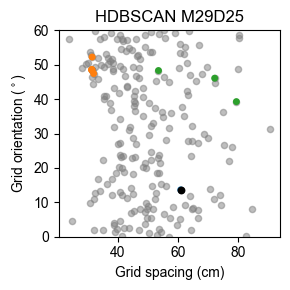

for module 0, there are 6 cells with average spacing 31.541636351465446
for module 1, there are 3 cells with average spacing 68.42440172931934
GC ((absolute ML distance)): Distance from grid module 1 has a significant effect on fold change in spatial information (slope=-8.44e-04, p=1.6e-14). Fold change decreases with distance.
NGS ((absolute ML distance)): Distance from grid module 1 has a significant effect on fold change in spatial information (slope=-2.33e-04, p=7.9e-14). Fold change decreases with distance.


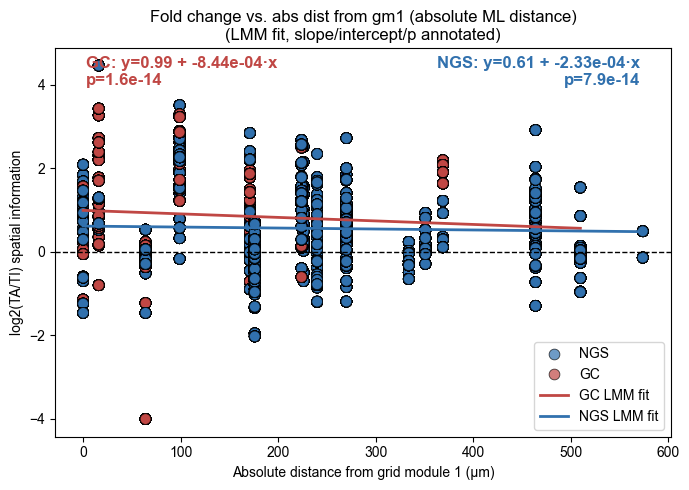

GC ((medial to lateral, ≥0)): Distance from grid module 1 has a significant effect on fold change in spatial information (slope=5.29e-04, p=0.00048). Fold change increases with distance.
NGS ((medial to lateral, ≥0)): Distance from grid module 1 has a significant effect on fold change in spatial information (slope=5.48e-05, p=3.7e-10). Fold change increases with distance.


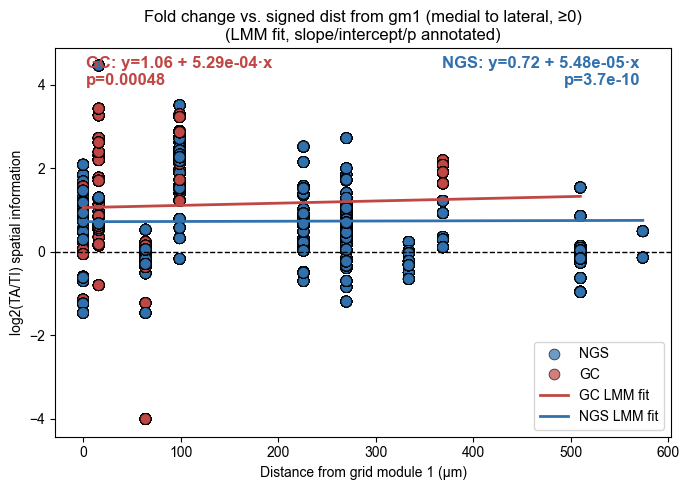

GC ((lateral to medial, ≤0)): No significant effect of distance on fold change in spatial information (slope=-1.27e-04, p=0.56).
NGS ((lateral to medial, ≤0)): Distance from grid module 1 has a significant effect on fold change in spatial information (slope=1.46e-03, p=3.6e-115). Fold change increases with distance.


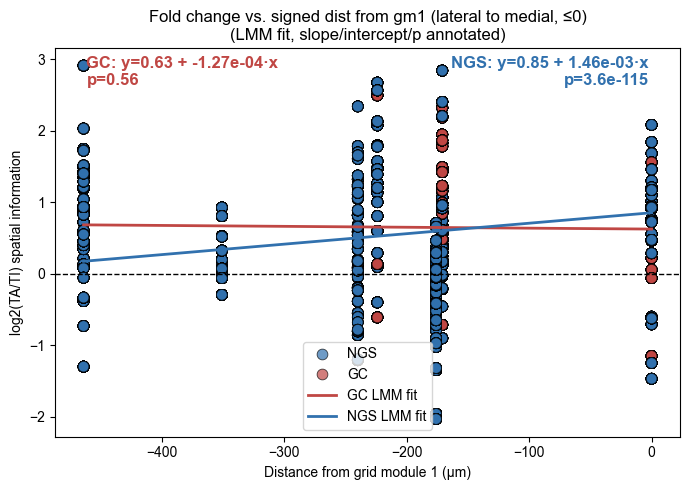

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Only keep the columns needed for merging and ML position from locations
locations_for_merge = locations[['cluster_id', 'mouse', 'day', 'coord_SCs_x']].copy()
locations_for_merge = locations_for_merge.rename(columns={'mouse': 'mouse_id', 'day': 'day_id'})

# Remove 'coord_SCs_x' from df_tidy if it already exists to avoid merge conflicts
if 'coord_SCs_x' in df_tidy.columns:
    df_tidy = df_tidy.drop(columns=['coord_SCs_x'])

df_tidy = df_tidy.merge(
    locations_for_merge,
    on=['cluster_id', 'mouse_id', 'day_id'],
    how='left'
)

# For each unique session, identify grid module 1 cells and compute mean ML position
session_means = []
for (mouse_id, day_id), session_df in df_tidy.groupby(['mouse_id', 'day_id']):
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse_id, day_id, percentile_threshold=95)
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse_id, day_id, min_cluster_size=3, cluster_selection_epsilon=3, 
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )
    module1_clusters = g_m_cluster_ids[0] if len(g_m_cluster_ids) > 0 else []
    ml_positions = locations_for_merge[
        (locations_for_merge['mouse_id'] == mouse_id) &
        (locations_for_merge['day_id'] == day_id) &
        (locations_for_merge['cluster_id'].isin(module1_clusters))
    ]['coord_SCs_x']
    mean_ml = ml_positions.mean() if len(ml_positions) > 0 else np.nan
    session_means.append({
        'mouse_id': mouse_id,
        'day_id': day_id,
        'mean_gm1_ml': mean_ml,
        'module1_clusters': set(module1_clusters)
    })

session_means_df = pd.DataFrame(session_means)

def get_session_mean_ml(row):
    match = session_means_df[
        (session_means_df['mouse_id'] == row['mouse_id']) &
        (session_means_df['day_id'] == row['day_id'])
    ]
    if not match.empty:
        return match.iloc[0]['mean_gm1_ml']
    return np.nan

def is_module1_cell(row):
    match = session_means_df[
        (session_means_df['mouse_id'] == row['mouse_id']) &
        (session_means_df['day_id'] == row['day_id'])
    ]
    if not match.empty:
        return row['cluster_id'] in match.iloc[0]['module1_clusters']
    return False

df_tidy['mean_gm1_ml'] = df_tidy.apply(get_session_mean_ml, axis=1)
df_tidy['is_gm1_cell'] = df_tidy.apply(is_module1_cell, axis=1)

# Compute signed and absolute distance from grid module 1 for each cell
df_tidy['signed_dist_from_gm1'] = df_tidy['coord_SCs_x'] - df_tidy['mean_gm1_ml']
df_tidy['abs_dist_from_gm1'] = np.abs(df_tidy['signed_dist_from_gm1'])

def plot_lmm_fit(df, xcol, title_suffix):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x=xcol,
        y='log2_fc',
        hue='cell_type',
        palette={'GC': '#c04744', 'NGS': '#3171ae'},
        alpha=0.7,
        edgecolor='k',
        s=60
    )
    for cell_type, color, xpos in zip(['GC', 'NGS'], ['#c04744', '#3171ae'], [0.05, 0.95]):
        sub = df[df['cell_type'] == cell_type].copy()
        sub = sub.dropna(subset=[xcol, 'log2_fc', 'mouse_id', 'day_id', 'cluster_id'])
        if len(sub) > 1:
            try:
                model = smf.mixedlm(
                    f"log2_fc ~ {xcol}",
                    sub,
                    groups=sub["mouse_id"],
                    re_formula="~1",
                    vc_formula={
                        "day": "0 + C(day_id)",
                        "cluster": "0 + C(cluster_id)",
                    }
                )
                result = model.fit()
                intercept = result.params.get('Intercept', np.nan)
                slope = result.params.get(xcol, np.nan)
                pval = result.pvalues.get(xcol, np.nan)
                # Plot the LMM fit line
                xfit = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
                yfit = intercept + slope * xfit
                plt.plot(xfit, yfit, color=color, lw=2, label=f'{cell_type} LMM fit')
                # Annotate slope, intercept, and p-value
                plt.gca().annotate(
                    f"{cell_type}: y={intercept:.2f} + {slope:.2e}·x\np={pval:.2g}",
                    xy=(xpos, 0.98), xycoords='axes fraction',
                    ha='left' if cell_type == 'GC' else 'right',
                    va='top', color=color, fontsize=12, fontweight='bold'
                )
                # Print statement explaining the result
                if np.isnan(pval):
                    print(f"{cell_type} ({title_suffix}): LMM fit failed or insufficient data.")
                elif pval < 0.05:
                    direction = "increases" if slope > 0 else "decreases"
                    print(f"{cell_type} ({title_suffix}): Distance from grid module 1 has a significant effect on fold change in spatial information (slope={slope:.2e}, p={pval:.2g}). Fold change {direction} with distance.")
                else:
                    print(f"{cell_type} ({title_suffix}): No significant effect of distance on fold change in spatial information (slope={slope:.2e}, p={pval:.2g}).")
            except Exception as e:
                print(f"LME failed for {cell_type} ({title_suffix}): {e}")
    plt.axhline(0, color='k', linestyle='--', lw=1)
    plt.xlabel('Distance from grid module 1 (μm)' if xcol == 'signed_dist_from_gm1' else 'Absolute distance from grid module 1 (μm)')
    plt.ylabel('log2(TA/TI) spatial information')
    plt.title(f'Fold change vs. {xcol.replace("_", " ")} {title_suffix}\n(LMM fit, slope/intercept/p annotated)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 1. Plot for absolute distance (all cells)
plot_lmm_fit(df_tidy, 'abs_dist_from_gm1', '(absolute ML distance)')
# 2. Plot for positive signed distances (medial to lateral, including 0)
plot_lmm_fit(df_tidy[df_tidy['signed_dist_from_gm1'] >= 0], 'signed_dist_from_gm1', '(medial to lateral, ≥0)')
# 3. Plot for negative signed distances (lateral to medial, including 0)
plot_lmm_fit(df_tidy[df_tidy['signed_dist_from_gm1'] <= 0], 'signed_dist_from_gm1', '(lateral to medial, ≤0)')